In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

<h4>Read and process annotation data</h4>

In [2]:
annotation_file = "full_annotation_df.csv"
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,Unnamed: 0,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
1,1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
2,2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
3,3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
4,4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993


In [3]:
annotation_df_bed = annotation_df.loc[:,["intended_target_region","gene_target"]].drop_duplicates()

In [4]:
annotation_df_bed["chr"] = annotation_df_bed["intended_target_region"].apply(lambda x: x.split(":")[0])
annotation_df_bed["start"] = annotation_df_bed["intended_target_region"].apply(
    lambda x: x.split(":")[1].split("-")[0])
annotation_df_bed["end"] = annotation_df_bed["intended_target_region"].apply(
    lambda x: x.split(":")[1].split("-")[1])

In [5]:
annotation_df_bed.loc[:,["chr","start","end","gene_target"]].to_csv("CP2_annotation_region.bed",
                                                                    sep="\t",
                                                                    header=None,
                                                                    index=None)

<h4>Read and process variant data</h4>

In [6]:
dnv_case = pd.read_csv("./Richter_DNV_case.txt",sep="\t",header=None)
dnv_case.columns = ["Chrom","Pos","Ref","Alt"]
dnv_case["Pos"] = dnv_case["Pos"]-1

dnv_control = pd.read_csv("./Richter_DNV_control.txt",sep="\t",header=None)
dnv_control.columns = ["Chrom","Pos","Ref","Alt"]
dnv_control["Pos"] = dnv_control["Pos"]-1

In [7]:
dnv_case.head()

,Chrom,Pos,Ref,Alt
0,chr1,823487,A,G
1,chr1,914810,G,C
2,chr1,919392,C,CG
3,chr1,958249,GATTT,G
4,chr1,958254,C,G


In [8]:
print(dnv_case.shape)
print(dnv_control.shape)

(58090, 4)
(117344, 4)


In [9]:
dnv_case["Pos_1"] = dnv_case["Pos"]+1
dnv_case["Name"] = dnv_case["Ref"]+"_"+dnv_case["Alt"]

dnv_control["Pos_1"] = dnv_control["Pos"]+1
dnv_control["Name"] = dnv_control["Ref"]+"_"+dnv_control["Alt"]

In [10]:
dnv_case.loc[:,["Chrom","Pos","Pos_1","Name"]].to_csv("Richter_DNV_case.bed",
                                                      sep="\t",
                                                      header=None,
                                                      index=None
                                                     )

dnv_control.loc[:,["Chrom","Pos","Pos_1","Name"]].to_csv("Richter_DNV_control.bed",
                                                      sep="\t",
                                                      header=None,
                                                      index=None
                                                     )

In [15]:
extension_len = 500
cmd = "bedtools slop -i CP2_annotation_region.bed -b "+str(extension_len)+" \
        -g /project/GCRB/Hon_lab/s223695/Data_project/reference/hg38/STAR_hg38/chrNameLength.txt \
        > CP2_annotation_region_"+str(extension_len)+".bed"
os.system(cmd)

0

In [16]:
cmd = "bedtools intersect -a CP2_annotation_region_"+str(extension_len)+".bed -b Richter_DNV_case.bed -wa > region_with_case_"+str(extension_len)+".bed"
os.system(cmd)

cmd = "bedtools intersect -a CP2_annotation_region_"+str(extension_len)+".bed -b Richter_DNV_control.bed -wa > region_with_control_"+str(extension_len)+".bed"
os.system(cmd)

0

In [23]:
region_with_case = pd.read_csv("region_with_case.bed",sep="\t",header=None)
region_with_case.columns = ["Chrom","Pos","Pos_1","Name"]

region_with_control = pd.read_csv("region_with_control.bed",sep="\t",header=None)
region_with_control.columns = ["Chrom","Pos","Pos_1","Name"]

In [24]:
print(region_with_case.shape)
print(region_with_control.shape)

(34, 4)
(90, 4)


In [25]:
pval_df = pd.read_csv("./Step2_pval_target.csv",index_col=0)

In [26]:
pval_df["case"] = np.isin(pval_df["region_name"],region_with_case["Name"])
pval_df["control"] = np.isin(pval_df["region_name"],region_with_control["Name"])

<Axes: xlabel='pval_mean_log', ylabel='Count'>

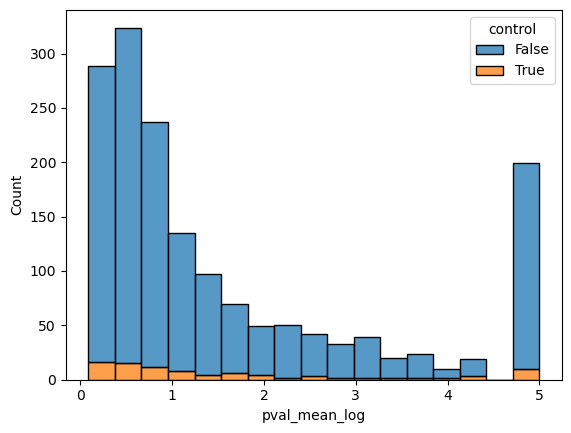

In [27]:
sns.histplot(data=pval_df,x="pval_mean_log",hue="control",multiple="stack")

In [28]:
pval_df_case = pval_df[pval_df["case"]].loc[:,["pval_mean_log","distance_mean_log","region_name","source"]]
pval_df_case = pval_df_case.sort_values("pval_mean_log",ascending=False)

pval_df_control = pval_df[pval_df["control"]].loc[:,["pval_mean_log","distance_mean_log","region_name","source"]]
pval_df_control = pval_df_control.sort_values("pval_mean_log",ascending=False)